This code is for processing TPM results obtained from salmon into a single file.
# The code is designed to read in multiple TPM files, extract the relevant columns, and merge them into a single file. 

In [38]:
import polars as pl
from pathlib import Path
import numpy as np

In [2]:
data_path = Path("../../data/salmon_results/")
files = data_path.glob("*/quant.sf")
files = list(files)
files

[WindowsPath('../../data/salmon_results/Ges1_A_10/quant.sf'),
 WindowsPath('../../data/salmon_results/Ges1_A_D/quant.sf'),
 WindowsPath('../../data/salmon_results/Ges1_P_10/quant.sf'),
 WindowsPath('../../data/salmon_results/Ges1_P_D/quant.sf'),
 WindowsPath('../../data/salmon_results/MCF10A_KO/quant.sf'),
 WindowsPath('../../data/salmon_results/MCF10A_P/quant.sf'),
 WindowsPath('../../data/salmon_results/OVCAR3_A1AKO/quant.sf'),
 WindowsPath('../../data/salmon_results/OVCAR3_P/quant.sf')]

In [15]:
dfs = dict()
for file in files:
    df = pl.read_csv(file, separator="\t")
    # print(df.shape)
    dfs['Gene'] = df['Name']
    dfs[file.parent.stem] = df['TPM'].to_numpy()

In [18]:
final_df = pl.from_dict(dfs) # contains transcript information too i guess
final_df

Gene,Ges1_A_10,Ges1_A_D,Ges1_P_10,Ges1_P_D,MCF10A_KO,MCF10A_P,OVCAR3_A1AKO,OVCAR3_P
str,f64,f64,f64,f64,f64,f64,f64,f64
"""ENST00000631435.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000415118.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000448914.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000434970.2""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000439842.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…
"""ENST00000640708.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000638534.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000640864.1""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
final_df.with_columns(
    pl.col('Gene').str.split('.').list.get(0)
)

Gene,Ges1_A_10,Ges1_A_D,Ges1_P_10,Ges1_P_D,MCF10A_KO,MCF10A_P,OVCAR3_A1AKO,OVCAR3_P
str,f64,f64,f64,f64,f64,f64,f64,f64
"""ENST00000631435""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000415118""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000448914""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000434970""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000439842""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…
"""ENST00000640708""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000638534""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENST00000640864""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
final_df.with_columns(
    pl.col('Gene').str.split('.').list.get(0)
).write_csv("../../data/salmon_results/combined_quant.tsv", separator="\t")

# TCGA - ARID1A analysis


In [5]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme()

In [12]:
df = pl.read_csv("../../data/TCGA-arid1a/STAD_RNASeq_recon_cleaned.tsv", separator="\t")
df = df.filter(~pl.col("GeneID").str.starts_with("ENSG"))
df.head()

GeneID,TCGA.BR.A4J4,TCGA.BR.A4IZ,TCGA.RD.A7C1,TCGA.BR.6852,TCGA.IP.7968,TCGA.BR.7851,TCGA.BR.A4J1,TCGA.BR.8487,TCGA.BR.6564,TCGA.D7.6526,TCGA.CD.8530,TCGA.FP.7735,TCGA.MX.A5UJ,TCGA.BR.4367,TCGA.D7.5578,TCGA.VQ.A8PX,TCGA.BR.8295,TCGA.D7.8579,TCGA.CG.5730,TCGA.HU.A4G8,TCGA.3M.AB46,TCGA.D7.8572,TCGA.VQ.A923,TCGA.BR.6710,TCGA.BR.6802,TCGA.VQ.A91N,TCGA.D7.8573,TCGA.VQ.A91E,TCGA.HF.A5NB,TCGA.HU.A4GC,TCGA.BR.A4QI,TCGA.VQ.A8PP,TCGA.BR.4255,TCGA.MX.A5UG,TCGA.CG.5732,TCGA.CG.5719,…,TCGA.CG.4304,TCGA.HU.A4G9,TCGA.CG.5723,TCGA.D7.8570,TCGA.IN.A6RN,TCGA.BR.4256,TCGA.EQ.8122,TCGA.FP.A8CX,TCGA.BR.8078,TCGA.HU.A4G2,TCGA.BR.8679,TCGA.BR.8289,TCGA.CG.5726,TCGA.BR.A4J9,TCGA.BR.8291,TCGA.BR.A4J2,TCGA.HU.8608,TCGA.HU.A4H8,TCGA.BR.A4PF,TCGA.BR.6705,TCGA.VQ.A928,TCGA.KB.A93J,TCGA.CD.A48A,TCGA.CD.5813,TCGA.VQ.A94O,TCGA.D7.A4YY,TCGA.RD.A8NB,TCGA.BR.8591,TCGA.VQ.AA6G,TCGA.R5.A7ZR,TCGA.BR.4201,TCGA.FP.A4BF,TCGA.BR.A44U,TCGA.VQ.A8PO,TCGA.CG.4476,TCGA.BR.7959,TCGA.CG.4306
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""8813.1""",1749.070193,1100.575238,2713.19719,1364.121383,1200.152827,850.878622,2323.496465,1244.116147,767.972299,1444.842497,1079.109318,1029.616296,919.29153,2289.778396,1224.762941,1368.482133,1092.780615,726.480753,1148.40468,1199.288296,2156.126169,1207.328304,1401.926437,1140.86745,1533.204716,1456.953816,2020.410227,1294.847935,891.935867,1910.827173,1956.951163,796.673155,1159.202022,626.433462,3220.609471,995.348731,…,1608.341436,1130.232861,1589.261771,1069.562407,1172.552347,936.757397,1930.004548,1207.233206,845.444677,2799.778693,2269.757595,1375.53443,1573.961319,1052.325697,1101.300406,1040.285238,1451.591265,1024.182821,1786.753274,646.118514,938.100472,1257.533803,1938.242797,1439.830064,2404.415549,908.704571,745.113005,955.759374,1380.473714,1237.519975,1985.139296,2997.878831,2269.741123,1033.20521,1443.785736,1066.240066,1444.268035
"""2268.1""",250.099173,459.994568,689.900768,576.088801,181.240209,374.278887,60.228565,317.56326,288.341248,171.328819,278.710354,229.904697,142.050316,437.751752,365.037259,130.499585,77.800257,491.347474,240.010502,171.007558,91.118845,552.791327,362.65111,217.055988,426.748416,77.520666,159.148548,224.228076,114.582701,124.141695,143.350474,272.902932,200.40035,588.965773,309.308744,511.812842,…,416.977409,48.942611,503.563842,1424.778467,154.10688,983.449355,226.532821,304.307174,606.660655,154.29492,181.045221,101.656124,79.438595,180.767605,500.406544,400.298327,604.90809,180.199864,548.130239,320.63024,213.070139,371.82084,362.851791,550.319664,916.975494,481.645532,449.622476,330.953945,148.238788,109.192939,779.446869,733.588347,113.279837,317.779959,271.892904,283.595807,357.671394
"""2519.1""",2581.380754,2087.034177,4823.117924,2017.022023,1944.049208,2578.664852,2785.985536,2882.899392,1869.295212,2645.97662,2049.235741,1861.038887,2244.556405,3267.462681,1867.983766,2873.636128,2829.425423,2091.875383,2655.306059,3481.624457,4509.323329,2438.691014,1826.236349,2244.676561,2601.04125,2981.285407,6046.67441,2852.679416,2955.630619,2490.473397,1971.612007,2087.453172,4415.407703,1512.511434,4252.995237,1936.971252,…,1902.678431,3405.495186,3471.376273,1243.745489,3879.473193,2693.542298,4030.769398,3606.151076,2978.084472,3939.014485,3034.092477,4024.947165,3565.311867,1305.03143,4413.32181,1579.737807,2718.79375,4458.538825,2625.110565,1927.02013,1352.40352,3213.246476,3105.283354,1974.574643,2733.292337,2370.980406,2443.119099,2932.578452,2345.878822,5464.196656,2196.875159,3461.701594,1812.477391,2812.10043,1933.365047,2031.768547,3524.195104
"""2729.1""",2656.897713,1266.455632,1157.053306,1204.807936,1705.100673,1150.660752,1142.132507,1168.319155,1348.874423,2765.082216,972.80633,1312.042325,1242.133156,2216.626246,1261.266

In [13]:
sil_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df.select(pl.exclude('GeneID')).to_numpy().T)
    sil_scores.append(silhouette_score(df.select(pl.exclude('GeneID')).to_numpy().T, kmeans.labels_))
    print(i, sil_scores[-1])

c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM

2 0.8612889605458061
3 0.5684413674931352
4 0.5287852554382207
5 0.4349198030566818
6 0.4474281613780218


c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM

7 0.3645212219884096
8 0.3157510500371089
9 0.37349590818356015
10 0.30963103323495805


c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


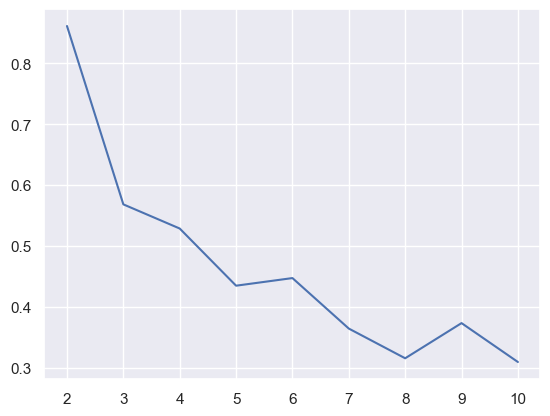

In [14]:
plt.plot(range(2, 11), sil_scores)

Text(0, 0.5, 'Silhouette score')

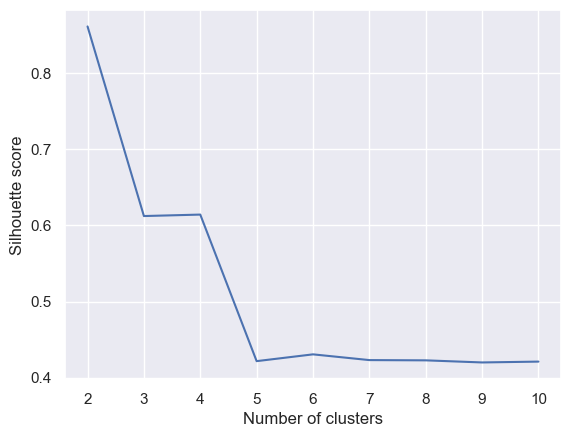

In [16]:
sil_scores_agg = []

for i in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=i)
    agg.fit(df.select(pl.exclude('GeneID')).to_numpy().T)
    sil_scores_agg.append(silhouette_score(df.select(pl.exclude('GeneID')).to_numpy().T, agg.labels_))
    
plt.plot(range(2, 11), sil_scores_agg)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")

In [17]:
len(agg.labels_)

412

In [18]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(df.select(pl.exclude('GeneID')).to_numpy().T)
kmeans.labels_

c:\Users\loksh\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [19]:
df2 = pl.read_csv("../../data/TCGA-arid1a/nl_STAD_RNASeq_meta.csv", ignore_errors=True)
df2

id,dex,dex2,dex3,dex4,dex5,dex6,ARID1A mutant,Truncating,Misense,,low,high
str,str,str,str,str,str,str,str,str,str,str,str,str
"""TCGA-3M-AB46""","""WT""","""WT""","""WT""","""high""",null,null,"""TCGA-B7-5816""","""TCGA-B7-5818""","""TCGA-BR-4370""",null,"""TCGA-RD-A7C1""","""TCGA-BR-A4J4"""
"""TCGA-3M-AB47""","""WT""","""WT""","""WT""","""normal""","""normal""","""normal""","""TCGA-B7-5818""","""TCGA-VQ-A8E3""","""TCGA-CG-4469""",null,"""TCGA-CG-5730""","""TCGA-BR-A4IZ"""
"""TCGA-B7-5816""","""mutant""","""mutant""","""Missense""","""normal""","""low""","""low""","""TCGA-B7-A5TI""","""TCGA-D7-8579""","""TCGA-D7-A6EY""",null,"""TCGA-BR-6710""","""TCGA-IP-7968"""
"""TCGA-B7-5818""","""mutant""","""Truncating""","""mutant""","""high""","""low""","""low""","""TCGA-B7-A5TK""","""TCGA-HU-A4G9""","""TCGA-VQ-A924""",null,"""TCGA-BR-6802""","""TCGA-BR-7851"""
"""TCGA-B7-A5TI""","""mutant""","""Truncating""","""mutant""","""normal""","""low""","""low""","""TCGA-BR-4184""","""TCGA-HU-A4GN""","""TCGA-BR-8680""",null,"""TCGA-CD-8532""","""TCGA-BR-A4J1"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""TCGA-VQ-AA6I""","""WT""","""WT""","""WT""","""high""","""normal""","""normal""",null,null,null,null,null,null
"""TCGA-VQ-AA6J""","""mutant""","""Truncating""","""mutant""","""normal""",null,null,null,null,null,null,null,null
"""TCGA-VQ-AA6K""","""WT""","""WT""","""WT""","""normal""","""normal""","""normal""",null,null,null,null,null,null


In [50]:
mutants = np.intersect1d(df2['ARID1A mutant'].drop_nulls().str.replace_all("-",".").to_list(), df.columns)
truncating = np.intersect1d(df2['Truncating'].drop_nulls().str.replace_all("-",".").to_list(), df.columns) #df2['Truncating'].drop_nulls().str.replace_all("-",".").to_list()
missense = np.intersect1d(df2['Misense'].drop_nulls().str.replace_all("-",".").to_list(), df.columns)
low = np.intersect1d(df2['low'].drop_nulls().str.replace_all("-",".").to_list(), df.columns) #df2['low'].drop_nulls().str.replace_all("-",".").to_list()
high = np.intersect1d(df2['high'].drop_nulls().str.replace_all("-",".").to_list(), df.columns) #df2['high'].drop_nulls().str.replace_all("-",".").to_list()

In [51]:
len(mutants) + len(truncating) + len(missense) 

223

In [52]:
len(low) + len(high)

206

In [53]:
df2['dex3'].value_counts()

dex3,count
str,u32
"""Missense""",19
"""mutant""",93
"""WT""",300


In [54]:
df2['dex2'].value_counts()


dex2,count
str,u32
"""Truncating""",93
"""mutant""",19
"""WT""",300


In [55]:
df2['dex4'].value_counts()


dex4,count
str,u32
"""normal""",206
"""low""",32
"""high""",174


In [59]:
temp = (
    df2
    .select('id', 'dex2')
    .group_by('dex2')
    .agg(bro = pl.col('id').str.replace_all("-","."))
)
temp

dex2,bro
str,list[str]
"""mutant""","[""TCGA.B7.5816"", ""TCGA.BR.4201"", … ""TCGA.IN.8663""]"
"""WT""","[""TCGA.3M.AB46"", ""TCGA.3M.AB47"", … ""TCGA.ZQ.A9CR""]"
"""Truncating""","[""TCGA.B7.5818"", ""TCGA.B7.A5TI"", … ""TCGA.VQ.AA6J""]"


In [60]:
id_dict = {i[0]: i[1] for i in temp.iter_rows()}

avg_tcga_df = pl.DataFrame(
    data = {
        'WT': id_dict['WT'],
        
    }
)

In [65]:
avg_df  = df.with_columns(
    WT = pl.mean_horizontal(id_dict['WT']),
    mutant = pl.mean_horizontal(id_dict['mutant']),
    Truncating = pl.mean_horizontal(id_dict['Truncating'])
).select('GeneID', 'WT', 'mutant', 'Truncating')

avg_df

GeneID,WT,mutant,Truncating
str,f64,f64,f64
"""8813.1""",1518.905266,1353.847858,1299.150256
"""2268.1""",335.024985,303.045647,358.242806
"""2519.1""",2805.942422,2626.083765,2801.737757
"""2729.1""",1783.112776,1612.687736,1528.590674
"""1080.1""",1998.800355,1276.361395,1510.067042
…,…,…,…
"""29128.1""",771.621759,1035.686312,1069.076106
"""N_ambiguous""",1.7970e6,1.7225e6,1.7986e6
"""N_multimapping""",1.0942e7,1.0174e7,1.1026e7


In [66]:
avg_df.write_csv("../../data/TCGA-arid1a/avg_STAD_recon_cleaned.tsv", separator="\t")